In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from collections import defaultdict

sys.path.append("./../../")
from utils_v2 import *
from utils_data_v2 import *

In [27]:
np.random.seed(42)

n_rct, n_rct_val = 20000, 10000
n_obs, n_obs_val = 20000, 10000
n_val = 1000

pl_range = (0.1, 0.2)
ph_range = (0.8, 0.9)

d = 5
d_meas = d - 1
predictors = [f"Xp{i + 1}" for i in range(2 ** d_meas)]

cov_res = defaultdict(lambda: defaultdict(list))
bias_res = list()
scenario = {"Y0": None, "Y1": "biased", "A": "biased", "S": None}
num_trials = 20

for _ in range(num_trials):
    obs_probs = sample_all_probs(d, pl_range, ph_range, scenario)
    obs_probs["A"] = obs_probs["Y1"]
    rct_probs = {"Y0": obs_probs["Y0"],
                "Y1": obs_probs["Y1"], 
                "A": (2 ** d) * [0.5],
                "S": (2 ** d) * [0.95],}

    df_rct     = init_df(n_rct, d, d_meas, 1, rct_probs)
    df_obs     = init_df(n_obs, d, d_meas, 0, obs_probs)
    df_rct_val = init_df(n_rct_val, d, d_meas, 1, rct_probs)
    df_obs_val = init_df(n_obs_val, d, d_meas, 0, obs_probs)

    rct_models = fit_models(df_rct, predictors)
    make_preds(df_rct_val, predictors, rct_models)
    
    obs_models = fit_models(df_obs, predictors)
    make_preds(df_obs_val, predictors, obs_models)

    pr_model = fit_model(pd.concat([df_rct, df_obs]), predictors, "R")
    df_val = merge_df_val(df_rct_val, df_obs_val, predictors, pr_model, rct_models, obs_models)

    bias_res.append(df_val["w1(X)"].mean())

    for key in ["SE_Y0", "SE_Y1", "SE_A", "SE_S"]:
        cov_res["Pearson"][key].append(pearsonr(df_val, "abs(w1(X))", key, n_val))
        # cov_res["Spearman"][key].append(spearmanr(df_val, "abs(w1(X))", key))

In [28]:
mse_s_y = list()
mse_s_a = list()
mse_s_s = list()

for i in range(2 ** d_meas):
    mse_s_y.append(df_val.query(f"Xp{i + 1}==1")["SE_Y1"].mean())
    mse_s_a.append(df_val.query(f"Xp{i + 1}==1")["SE_A"].mean())
    mse_s_s.append(df_val.query(f"Xp{i + 1}==1")["SE_S"].mean())

df_val["MSE_Y1"] = df_val.apply(lambda row: mse_s_y[np.where(np.array(row[predictors])==1)[0][0]],axis=1)
df_val["MSE_A"] = df_val.apply(lambda row: mse_s_a[np.where(np.array(row[predictors])==1)[0][0]],axis=1)
df_val["MSE_S"] = df_val.apply(lambda row: mse_s_s[np.where(np.array(row[predictors])==1)[0][0]],axis=1)

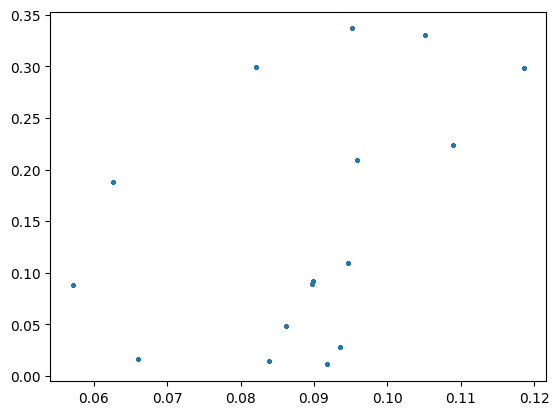

In [29]:
plt.scatter(df_val.query("R==0")["MSE_S"], df_val.query("R==0")["abs(w1(X))"], s=2)

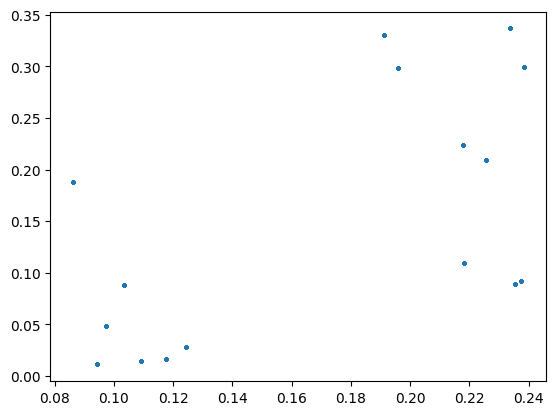

In [30]:
plt.scatter(df_val.query("R==0")["MSE_Y1"], df_val.query("R==0")["abs(w1(X))"],s=2)

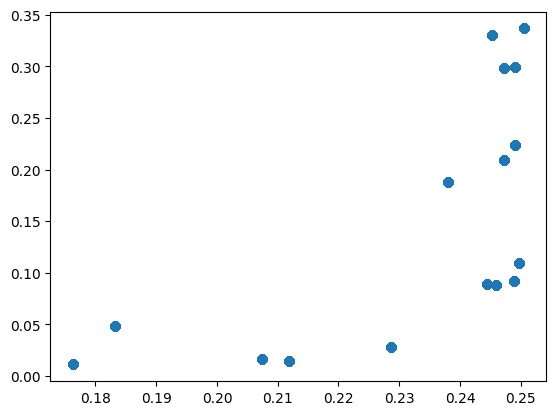

In [31]:
plt.scatter(df_val.query("R==0")["MSE_A"], df_val.query("R==0")["abs(w1(X))"])

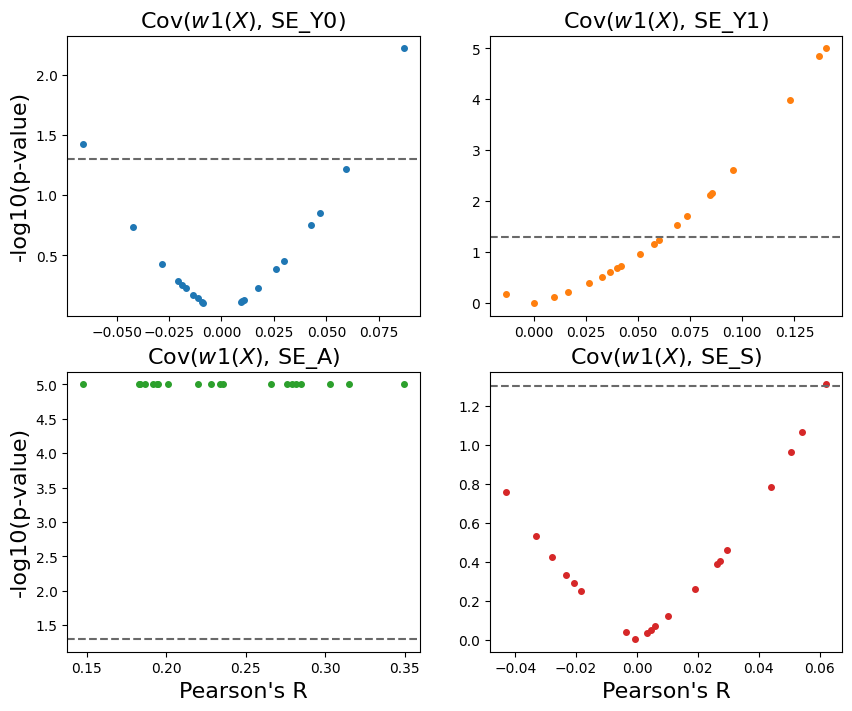

In [32]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(10,8)) 

for idx, key in enumerate(cov_res["Pearson"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($w1(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(cov_res["Pearson"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()

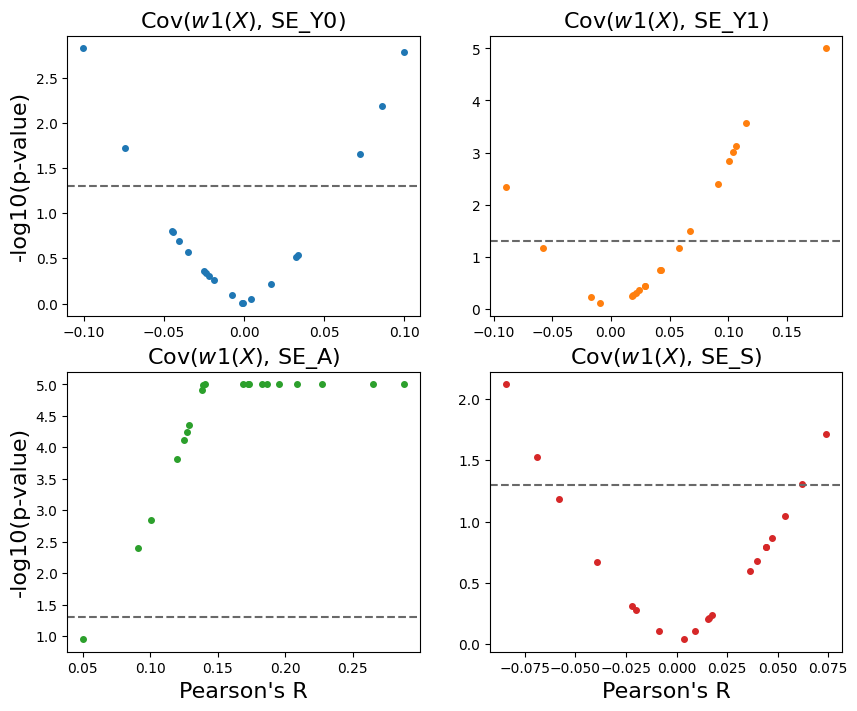

In [26]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(10,8)) 

for idx, key in enumerate(cov_res["Pearson"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($w1(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(cov_res["Pearson"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()

In [ ]:
len(np.where(np.array(cov_res["val1"]["SE_Y1"][1]) < 0.05)[0])

In [ ]:
cov_res

In [ ]:
df_val.query("R==0 & S==1")

In [ ]:
len(np.where(np.array(cov_res["val1"]["SE_A"])[:, 1] < 0.05)[0])